In [19]:
import numpy as np

data = np.load("/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_test_normal.npz")

print(data.files)

['X', 'H', 'scan_ids']


In [ ]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans = np.unique(scan_ids)

print("Number of unique scans:", len(unique_scans))

for s in unique_scans:
    print(s)

Number of unique scans: 82
train_10938_a_1
train_10991_a_1
train_11023_b_1
train_11150_b_2
train_11164_b_2
train_1119_b_2
train_11522_a_1
train_11880_d_1
train_1188_c_2
train_1192_a_2
train_1213_a_2
train_122_b_1
train_12309_a_1
train_12563_e_1
train_1292_b_2
train_1310_b_2
train_1329_b_1
train_13316_a_2
train_1348_g_2
train_1405_a_2
train_1409_a_2
train_1448_c_2
train_1496_a_1
train_1504_b_2
train_1540_a_1
train_1560_a_2
train_1591_c_2
train_1686_a_1
train_1756_a_1
train_1758_a_2
train_1758_b_2
train_1767_a_2
train_1868_a_2
train_186_a_2
train_1976_a_2
train_2167_a_2
train_2319_a_1
train_2806_a_2
train_2857_a_1
train_2886_a_2
train_2965_b_2
train_2986_c_2
train_2993_a_2
train_340_a_1
train_355_a_1
train_412_b_2
train_5231_a_2
train_5529_a_2
train_5822_a_2
train_5895_a_2
train_6335_b_1
train_6429_a_1
train_644_b_2
train_644_c_2
train_644_d_1
train_6629_a_1
train_6671_a_2
train_6970_a_2
train_6970_b_2
train_7062_a_2
train_7139_a_1
train_7145_a_2
train_7244_a_1
train_7250_b_2
train_7250_

In [30]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

unique_scans, counts = np.unique(
    scan_ids,
    return_counts=True
)

# Sort by least number of patches
least_idx = np.argsort(counts)

print("Scans with the fewest patches:\n")

for i in least_idx[:20]:   # show 20 least frequent scans
    print(f"{unique_scans[i]} : {counts[i]} patches")

Scans with the fewest patches:

train_7139_a_1 : 6 patches
train_2857_a_1 : 6 patches
train_1119_b_2 : 8 patches
train_13316_a_2 : 12 patches
train_644_d_1 : 12 patches
train_8072_a_2 : 12 patches
train_7697_a_2 : 12 patches
train_6335_b_1 : 14 patches
train_11522_a_1 : 15 patches
train_8048_a_2 : 15 patches
train_5895_a_2 : 15 patches
train_12563_e_1 : 24 patches
train_6671_a_2 : 32 patches
train_1591_c_2 : 36 patches
valid_918_a_2 : 39 patches
train_11150_b_2 : 45 patches
train_1976_a_2 : 46 patches
train_7674_a_2 : 48 patches
train_7250_b_2 : 53 patches
train_355_a_1 : 53 patches


In [33]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)

X = data["X"]
scan_ids = data["scan_ids"]
coords = data["coords"]
H = data["H"]

target_scan = "train_13316_a_2"

# Find patch indices
indices = np.where(scan_ids == target_scan)[0]

print("Number of patches:", len(indices))
print("Patch matrix column indices:")
print(indices)

Number of patches: 12
Patch matrix column indices:
[21192 21193 21194 21195 21196 21197 21198 21199 21200 21201 21202 21203]


In [29]:
coords = data["coords"]
scan_ids = data["scan_ids"]

indices = np.where(
    scan_ids == "train_13316_a_2"
)[0]

print("Indices:")
print(indices)

print("\nCoordinates:")
print(coords[indices])

Indices:
[21192 21193 21194 21195 21196 21197 21198 21199 21200 21201 21202 21203]

Coordinates:
[[162  91  63]
 [162  91  67]
 [162  91  71]
 [162  95  63]
 [162  95  67]
 [162  95  71]
 [166  91  63]
 [166  91  67]
 [166  91  71]
 [166  95  63]
 [166  95  67]
 [166  95  71]]


In [1]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

print(data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

['Gamma', 'labels']
Gamma (28672, 117387) float64
labels (117387,) int64


In [3]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

Gamma = data["Gamma"]
labels = data["labels"]

normal_idx = labels == 2

Gamma_normal = Gamma[:, normal_idx]

print("Normal sparse codes:", Gamma_normal.shape)

Normal sparse codes: (28672, 40592)


In [22]:
nonzero_per_patch = np.count_nonzero(Gamma_normal, axis=0)

print("Average active atoms:",
      nonzero_per_patch.mean())

print("Median active atoms:",
      np.median(nonzero_per_patch))

print("Min:",
      nonzero_per_patch.min())

print("Max:",
      nonzero_per_patch.max())

Average active atoms: 7.741426882144265
Median active atoms: 10.0
Min: 0
Max: 10


In [23]:
atom_usage = np.count_nonzero(Gamma_normal, axis=1)

top_atoms = np.argsort(atom_usage)[::-1]

for i in top_atoms[:20]:
    print(
        f"Atom {i}: used by {atom_usage[i]} patches "
        f"({100*atom_usage[i]/Gamma_normal.shape[1]:.2f}%)"
    )

Atom 14811: used by 632 patches (1.56%)
Atom 27268: used by 388 patches (0.96%)
Atom 27441: used by 376 patches (0.93%)
Atom 25049: used by 363 patches (0.89%)
Atom 24966: used by 363 patches (0.89%)
Atom 25701: used by 361 patches (0.89%)
Atom 27170: used by 353 patches (0.87%)
Atom 27890: used by 350 patches (0.86%)
Atom 24594: used by 347 patches (0.85%)
Atom 25166: used by 343 patches (0.84%)
Atom 28141: used by 333 patches (0.82%)
Atom 28254: used by 327 patches (0.81%)
Atom 24964: used by 324 patches (0.80%)
Atom 28490: used by 321 patches (0.79%)
Atom 25968: used by 320 patches (0.79%)
Atom 25608: used by 318 patches (0.78%)
Atom 27395: used by 317 patches (0.78%)
Atom 28280: used by 317 patches (0.78%)
Atom 28602: used by 317 patches (0.78%)
Atom 25777: used by 315 patches (0.78%)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

Gamma = data["Gamma"]
labels = data["labels"]

# Normal class
normal_idx = labels == 2
Gamma_normal = Gamma[:, normal_idx]

# Atom usage frequency
atom_usage = np.count_nonzero(Gamma_normal, axis=1)

top_atoms = np.argsort(atom_usage)[::-1]

print("Top atoms:")
for i in top_atoms[:20]:
    print(
        f"Atom {i}: "
        f"{atom_usage[i]} patches "
        f"({100*atom_usage[i]/Gamma_normal.shape[1]:.2f}%)"
    )

Top atoms:
Atom 14811: 632 patches (1.56%)
Atom 27268: 388 patches (0.96%)
Atom 27441: 376 patches (0.93%)
Atom 25049: 363 patches (0.89%)
Atom 24966: 363 patches (0.89%)
Atom 25701: 361 patches (0.89%)
Atom 27170: 353 patches (0.87%)
Atom 27890: 350 patches (0.86%)
Atom 24594: 347 patches (0.85%)
Atom 25166: 343 patches (0.84%)
Atom 28141: 333 patches (0.82%)
Atom 28254: 327 patches (0.81%)
Atom 24964: 324 patches (0.80%)
Atom 28490: 321 patches (0.79%)
Atom 25968: 320 patches (0.79%)
Atom 25608: 318 patches (0.78%)
Atom 27395: 317 patches (0.78%)
Atom 28280: 317 patches (0.78%)
Atom 28602: 317 patches (0.78%)
Atom 25777: 315 patches (0.78%)


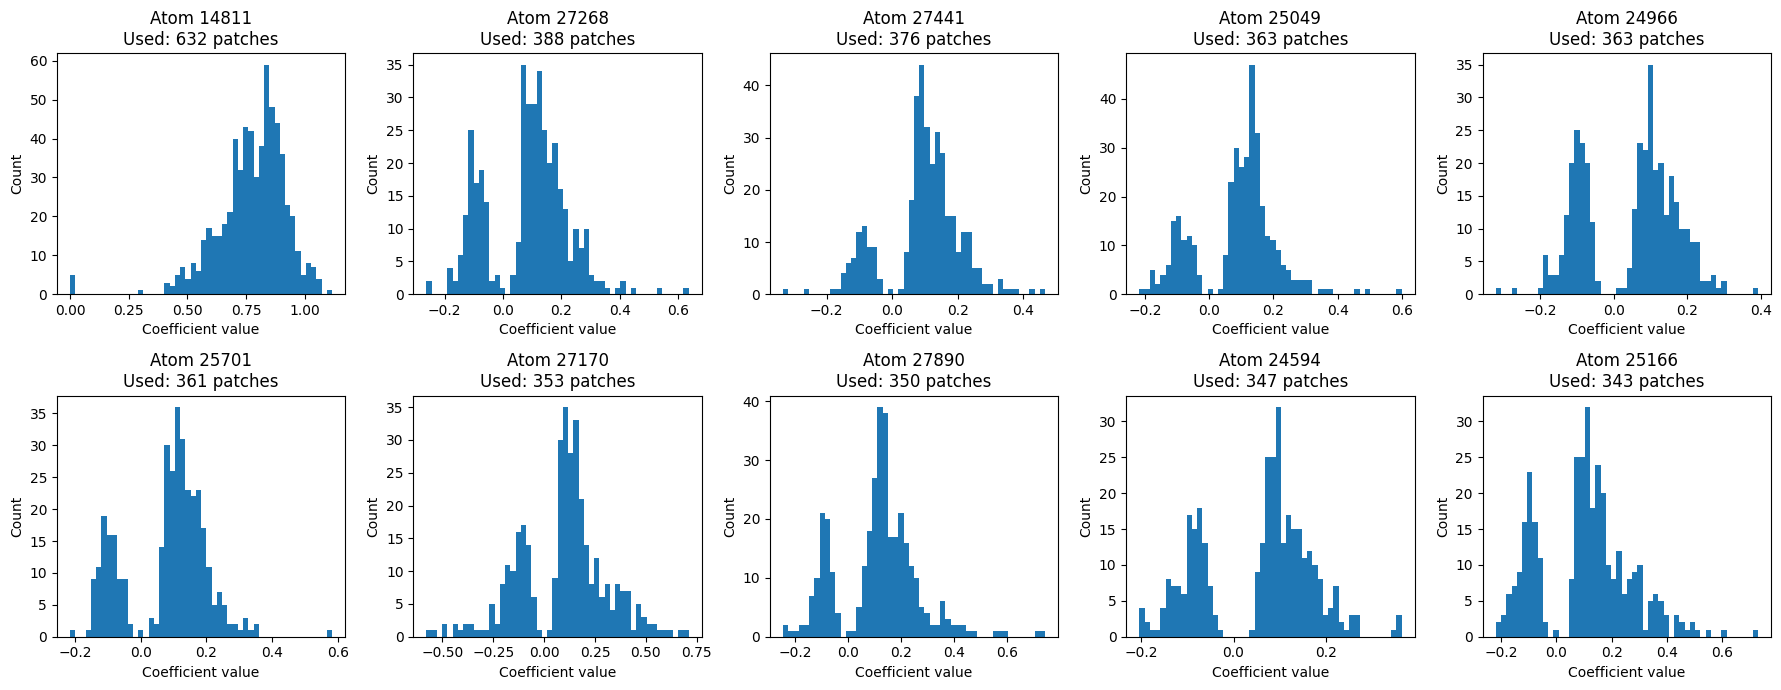

In [35]:
top_k = 10

fig, axes = plt.subplots(
    2,
    5,
    figsize=(18,7)
)

axes = axes.flatten()

for ax, atom in zip(
    axes,
    top_atoms[:top_k]
):

    # coefficients of this atom across normal patches
    coefficients = Gamma_normal[atom, :]

    # only active coefficients
    active_coeffs = coefficients[
        coefficients != 0
    ]

    ax.hist(
        active_coeffs,
        bins=50
    )

    ax.set_title(
        f"Atom {atom}\n"
        f"Used: {len(active_coeffs)} patches"
    )

    ax.set_xlabel("Coefficient value")
    ax.set_ylabel("Count")


plt.tight_layout()
plt.show()

Sparse codes shape: (28672, 117386)
Atom contribution shape: (28672,)


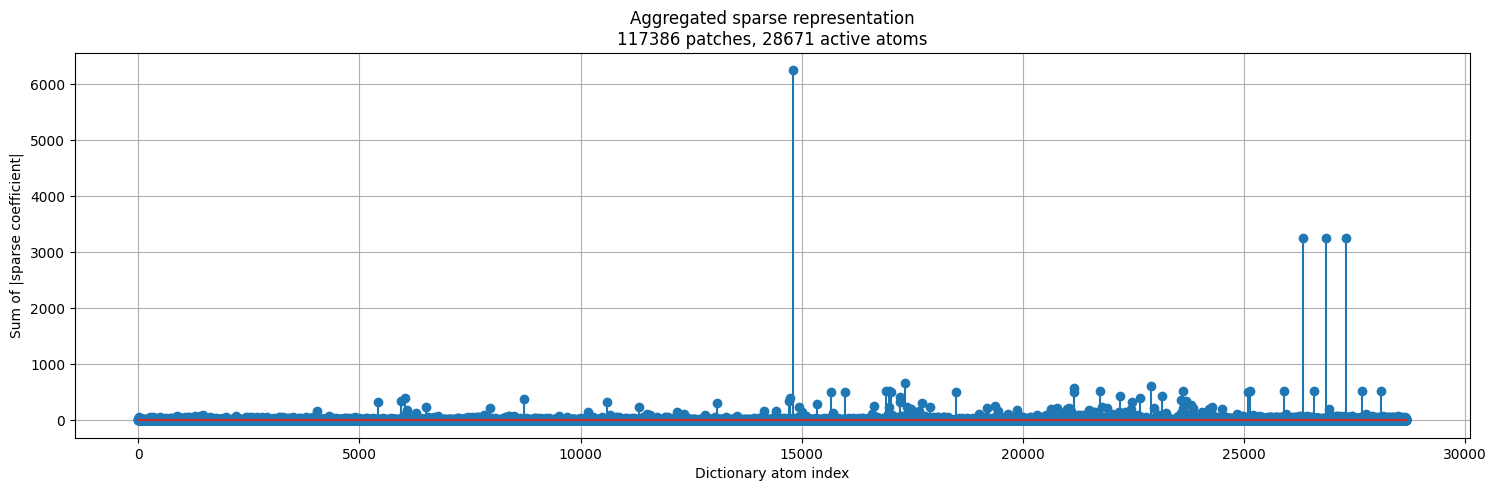

In [4]:
import numpy as np
import matplotlib.pyplot as plt

gamma_indices = np.arange(0, 117386)

# Extract sparse codes
Gamma_patches = Gamma[:, gamma_indices]

print("Sparse codes shape:", Gamma_patches.shape)

# Absolute coefficients
Gamma_abs = np.abs(Gamma_patches)

# Sum contribution of each atom across all patches
atom_contribution = np.sum(
    Gamma_abs,
    axis=1
)

print("Atom contribution shape:", atom_contribution.shape)


# Only plot atoms that contributed
active_atoms = np.where(atom_contribution > 0)[0]
active_values = atom_contribution[active_atoms]


plt.figure(figsize=(18,5))

plt.stem(
    active_atoms,
    active_values
)

plt.xlabel("Dictionary atom index")
plt.ylabel("Sum of |sparse coefficient|")
plt.title(
    f"Aggregated sparse representation\n"
    f"{len(gamma_indices)} patches, "
    f"{len(active_atoms)} active atoms"
)

plt.grid(True)
plt.show()

In [5]:
# Get top 10 contributing atoms
top_10_atoms = np.argsort(atom_contribution)[::-1][:10]

print("Top 10 atoms by summed |coefficient|:\n")

for atom in top_10_atoms:
    print(
        f"Atom {atom}: "
        f"Total |coefficient| = {atom_contribution[atom]:.6f}"
    )

Top 10 atoms by summed |coefficient|:

Atom 14811: Total |coefficient| = 6243.900989
Atom 27296: Total |coefficient| = 3257.594460
Atom 26844: Total |coefficient| = 3257.527581
Atom 26325: Total |coefficient| = 3257.527581
Atom 17329: Total |coefficient| = 669.332990
Atom 22904: Total |coefficient| = 613.163820
Atom 21148: Total |coefficient| = 566.147346
Atom 27668: Total |coefficient| = 517.624199
Atom 25143: Total |coefficient| = 516.835504
Atom 23618: Total |coefficient| = 516.721757


Top 4 atoms: [14811 27296 26844 26325 17329 22904 21148 27668 25143 23618]

Atom coefficients:
Atom 14811: 6226.458034
Atom 27296: -3257.460702
Atom 26844: -3257.527581
Atom 26325: -3257.527581
Atom 17329: 662.980558
Atom 22904: 605.507587
Atom 21148: 561.554772
Atom 27668: -514.883214
Atom 25143: -515.671909
Atom 23618: -515.785656

Combined patch shape: (4096,)


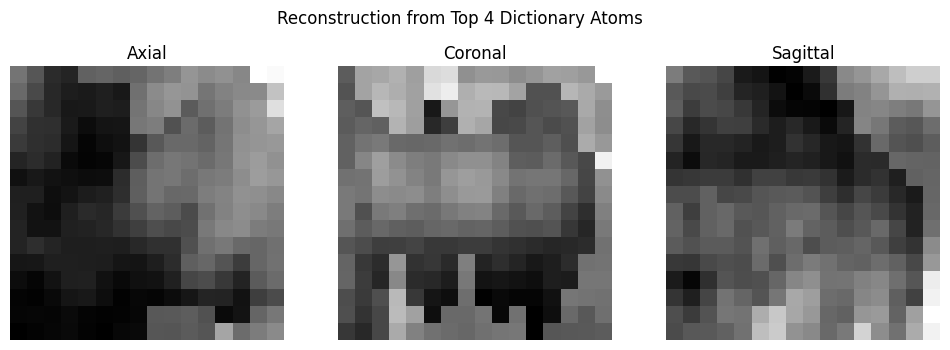

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model = pickle.load(f)

ksvd = model["model"]
D = ksvd.D_


# Take top 4 atoms from previous calculation
top_4_atoms = top_10_atoms[:10]

print("Top 4 atoms:", top_4_atoms)


# Aggregate coefficient for each selected atom
# (sum of signed coefficients across all patches)
atom_coefficients = np.sum(
    Gamma_patches[top_4_atoms, :],
    axis=1
)

print("\nAtom coefficients:")
for atom, coef in zip(top_4_atoms, atom_coefficients):
    print(f"Atom {atom}: {coef:.6f}")


# Reconstruct contribution of each atom
# D[:, atom] * coefficient
atom_contributions = []

for atom, coef in zip(top_4_atoms, atom_coefficients):

    patch = D[:, atom] * coef

    atom_contributions.append(
        patch
    )


# Superimpose the 4 atom contributions
combined_patch = np.sum(
    atom_contributions,
    axis=0
)


print("\nCombined patch shape:", combined_patch.shape)


# Convert to 3D
combined_patch_3d = combined_patch.reshape(
    16,16,16
)


# Visualize
mid = 8

fig, axes = plt.subplots(
    1,3,
    figsize=(12,4)
)

axes[0].imshow(
    combined_patch_3d[:,:,mid],
    cmap="gray"
)
axes[0].set_title("Axial")

axes[1].imshow(
    combined_patch_3d[:,mid,:],
    cmap="gray"
)
axes[1].set_title("Coronal")

axes[2].imshow(
    combined_patch_3d[mid,:,:],
    cmap="gray"
)
axes[2].set_title("Sagittal")


for ax in axes:
    ax.axis("off")

plt.suptitle(
    "Reconstruction from Top 4 Dictionary Atoms"
)

plt.show()

In [ ]:
import numpy as np
import pickle

# Load sparse codes
sparse_data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/sparse_codes/train_sparse_codes.npz",
    allow_pickle=True
)

Gamma = sparse_data["Gamma"]

# Select 97992nd sparse code
idx = 97991
gamma = Gamma[:, idx]

print("Sparse code shape:", gamma.shape)


# Load dictionary
with open(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/models/unified_frozen.pkl",
    "rb"
) as f:
    model = pickle.load(f)

print(type(model))
print(model.keys() if isinstance(model, dict) else model)

Sparse code shape: (28672,)
<class 'dict'>
dict_keys(['model', 'algorithm', 'class_order', 'config', 'patch_size', 'target_spacing', 'hu_window', 'training_time_s'])


In [9]:
ksvd = model["model"]

print(type(ksvd))
print(ksvd.__dict__.keys())

<class 'reppi.dictionary.frozen.frozen.IncrementalFrozenDictionary'>
dict_keys(['base_learner_class', 'base_learner_kwargs', 'residual_learner_class', 'residual_learner_kwargs', 'n_nonzero_coefs', 'D_', 'base_class_label_', 'class_labels_', 'class_boundaries_', 'stage_learners_', 'errors_'])


In [10]:
print(ksvd.D_.shape)

(4096, 28672)


Dictionary shape: (4096, 28672)
Reconstructed patch shape: (4096,)


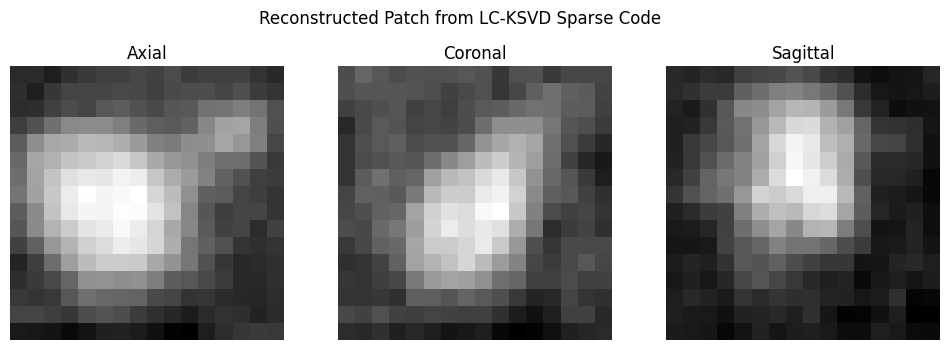

In [21]:
D = ksvd.D_

idx = 97991
gamma = Gamma[:, idx]

reconstructed_patch = D @ gamma

print("Dictionary shape:", D.shape)
print("Reconstructed patch shape:", reconstructed_patch.shape)

patch_3d = reconstructed_patch.reshape(16, 16, 16)

import matplotlib.pyplot as plt

# Choose center slices
mid = 8

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial view
axes[0].imshow(
    patch_3d[:, :, mid],
    cmap="gray"
)
axes[0].set_title("Axial")

# Coronal view
axes[1].imshow(
    patch_3d[:, mid, :],
    cmap="gray"
)
axes[1].set_title("Coronal")

# Sagittal view
axes[2].imshow(
    patch_3d[mid, :, :],
    cmap="gray"
)
axes[2].set_title("Sagittal")

for ax in axes:
    ax.axis("off")

plt.suptitle("Reconstructed Patch from LC-KSVD Sparse Code")
plt.show()

(4096, 12)
(12, 16, 16, 16)


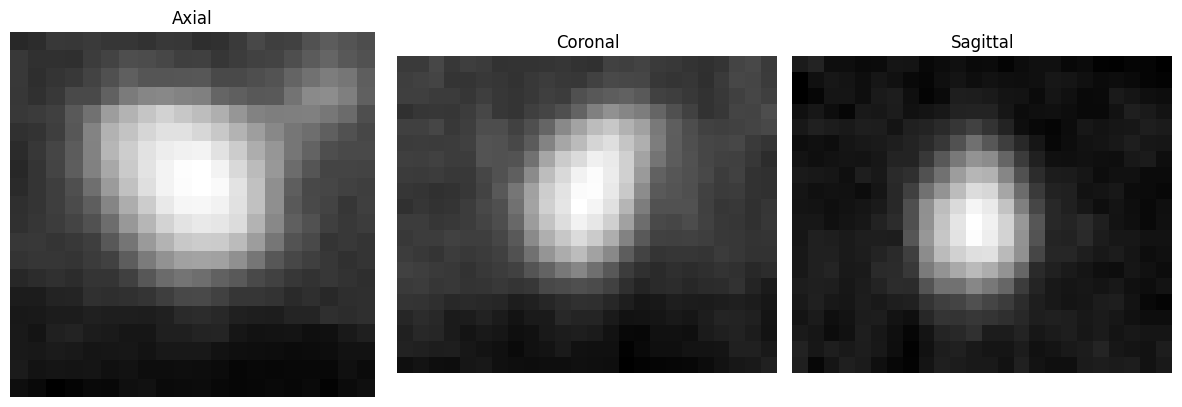

In [33]:
# Assumed sparse code indices
gamma_indices = np.arange(97987, 97999)

# Extract the 12 sparse codes
gamma = Gamma[:, gamma_indices]

# Reconstruct all patches
reconstructed = D @ gamma

print(reconstructed.shape)

patches = reconstructed.T.reshape(-1, 16, 16, 16)

print(patches.shape)

coords12 = np.array([
[162,91,63],
[162,91,67],
[162,91,71],
[162,95,63],
[162,95,67],
[162,95,71],
[166,91,63],
[166,91,67],
[166,91,71],
[166,95,63],
[166,95,67],
[166,95,71]
])

min_coord = coords12.min(axis=0)
max_coord = coords12.max(axis=0)

shape = tuple(max_coord - min_coord + 16)

volume = np.zeros(shape)
weight = np.zeros(shape)

for patch, coord in zip(patches, coords12):

    x, y, z = coord - min_coord

    volume[x:x+16, y:y+16, z:z+16] += patch
    weight[x:x+16, y:y+16, z:z+16] += 1

volume /= np.maximum(weight, 1)

# Visualize the reconstructed volume

import matplotlib.pyplot as plt

cx, cy, cz = np.array(volume.shape) // 2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(volume[:, :, cz], cmap="gray")
ax[0].set_title("Axial")

ax[1].imshow(volume[:, cy, :], cmap="gray")
ax[1].set_title("Coronal")

ax[2].imshow(volume[cx, :, :], cmap="gray")
ax[2].set_title("Sagittal")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np

data = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_test_normal.npz",
    allow_pickle=True
)

scan_ids = data["scan_ids"]

print("Shape:", scan_ids.shape)
print("Type:", type(scan_ids))
print("Dtype:", scan_ids.dtype)

print("Total scan IDs:", scan_ids.shape[0])
print("Unique scan IDs:", np.unique(scan_ids))
print("Number of unique scan IDs:", len(np.unique(scan_ids)))

Shape: (5850,)
Type: <class 'numpy.ndarray'>
Dtype: object
Total scan IDs: 5850
Unique scan IDs: ['train_12132_a_2' 'train_14336_a_2' 'train_15753_a_2' 'train_15829_a_1'
 'train_16003_a_2' 'train_16110_a_1' 'train_16404_a_1' 'train_17370_a_1'
 'train_17896_b_2' 'train_18107_a_2' 'train_19798_a_2' 'train_2510_a_1'
 'train_3994_a_1' 'train_4335_a_2' 'train_437_a_1' 'train_5425_a_2'
 'train_5864_b_1' 'train_5977_a_2' 'train_6321_b_2' 'train_783_a_2'
 'train_8143_a_1']
Number of unique scan IDs: 21


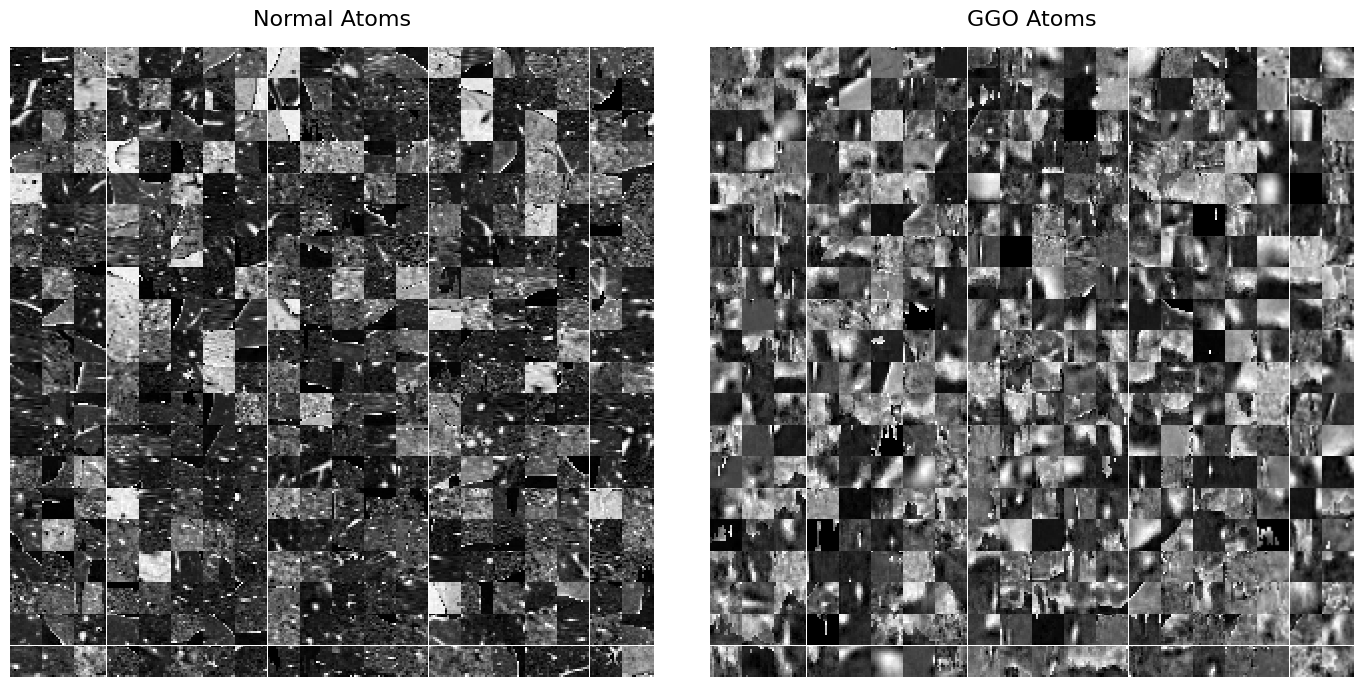

In [21]:
import numpy as np
import matplotlib.pyplot as plt

PATCH_SIZE = 16
MIDDLE = PATCH_SIZE // 2

rng = np.random.default_rng(42)

# Select 400 random atoms from each class
normal_atoms = rng.choice(
    np.arange(0, 16384),
    size=400,
    replace=False
)

ggo_atoms = rng.choice(
    np.arange(16384, 24576),
    size=400,
    replace=False
)


def plot_grid(fig, left, right, atom_ids, title):

    gs = fig.add_gridspec(
        20,
        20,
        left=left,
        right=right,
        top=0.92,
        bottom=0.02,
        wspace=0,
        hspace=0
    )

    axes = []

    for i in range(20):
        for j in range(20):
            ax = fig.add_subplot(gs[i, j])
            ax.axis("off")
            axes.append(ax)

    fig.text(
        (left + right) / 2,
        0.95,
        title,
        ha="center",
        fontsize=16
    )

    for ax, atom_id in zip(axes, atom_ids):

        atom = D[:, atom_id].reshape(
            PATCH_SIZE,
            PATCH_SIZE,
            PATCH_SIZE
        )

        ax.imshow(
            atom[MIDDLE],
            cmap="gray"
        )

        ax.axis("off")


fig = plt.figure(figsize=(14, 7))


# Normal atoms
plot_grid(
    fig,
    0.02,
    0.48,
    normal_atoms,
    "Normal Atoms"
)


# GGO atoms
plot_grid(
    fig,
    0.52,
    0.98,
    ggo_atoms,
    "GGO Atoms"
)


plt.show()

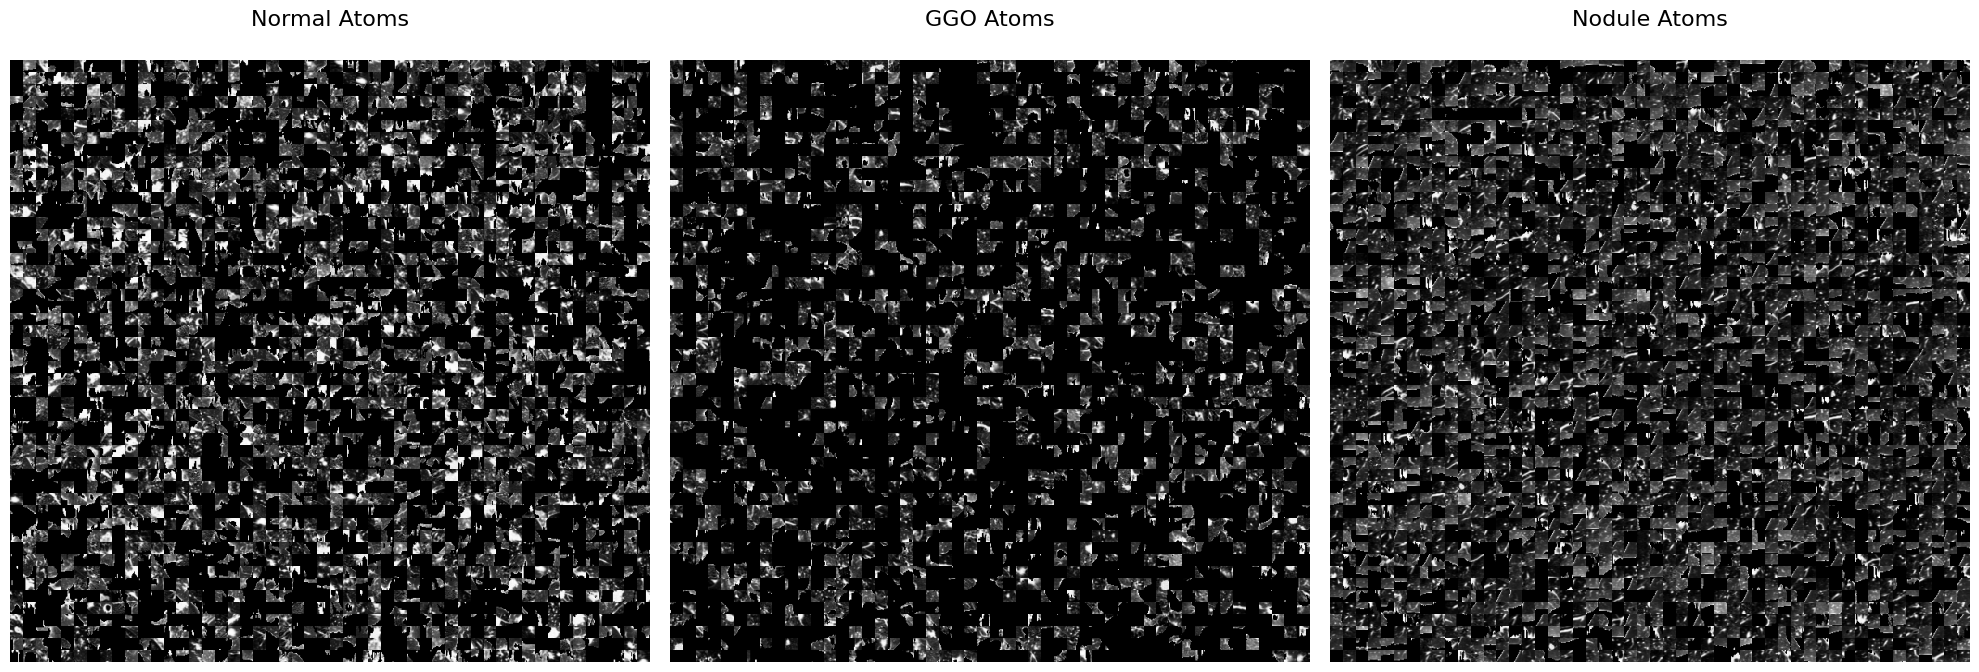

In [6]:
import numpy as np
import matplotlib.pyplot as plt

D = np.load(
    "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/outputs/patches/unified_train_2d.npz",
    allow_pickle=True
)["X"]

PATCH_SIZE = 16
MIDDLE = PATCH_SIZE // 2

rng = np.random.default_rng(42)

GRID_SIZE = 50
N_ATOMS = GRID_SIZE * GRID_SIZE  # 900

normal_atoms = rng.choice(
    np.arange(0, 16384),
    size=N_ATOMS,
    replace=False
)

ggo_atoms = rng.choice(
    np.arange(16384, 24576),
    size=N_ATOMS,
    replace=False
)

nodule_atoms = rng.choice(
    np.arange(24576, 28672),
    size=N_ATOMS,
    replace=False
)

def plot_grid(fig, left, right, atom_ids, title):

    gs = fig.add_gridspec(
        GRID_SIZE,
        GRID_SIZE,
        left=left,
        right=right,
        top=0.88,
        bottom=0.02,
        wspace=0,
        hspace=0
    )

    axes = []

    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            ax = fig.add_subplot(gs[i, j])
            ax.axis("off")
            axes.append(ax)

    fig.text(
        (left + right) / 2,
        0.93,
        title,
        ha="center",
        fontsize=16
    )

    for ax, atom_id in zip(axes, atom_ids):
        atom = D[:, atom_id].reshape(
            PATCH_SIZE,
            PATCH_SIZE,
            PATCH_SIZE
        )

        ax.imshow(atom[MIDDLE], cmap="gray")
        ax.axis("off")


fig = plt.figure(figsize=(20, 7))


# Normal atoms
plot_grid(
    fig,
    0.01,
    0.33,
    normal_atoms,
    "Normal Atoms"
)


# GGO atoms
plot_grid(
    fig,
    0.34,
    0.66,
    ggo_atoms,
    "GGO Atoms"
)


# Nodule atoms
plot_grid(
    fig,
    0.67,
    0.99,
    nodule_atoms,
    "Nodule Atoms"
)


plt.show()

Total CTs: 347


Processing CTs: 100%|██████████| 347/347 [27:55<00:00,  4.83s/it] 



Saved: normal_lung_voxels_with_meta.npz
Total CTs saved: 347

Example CT:
CT name: train_12342_a_1
Voxel shape: (647180,)


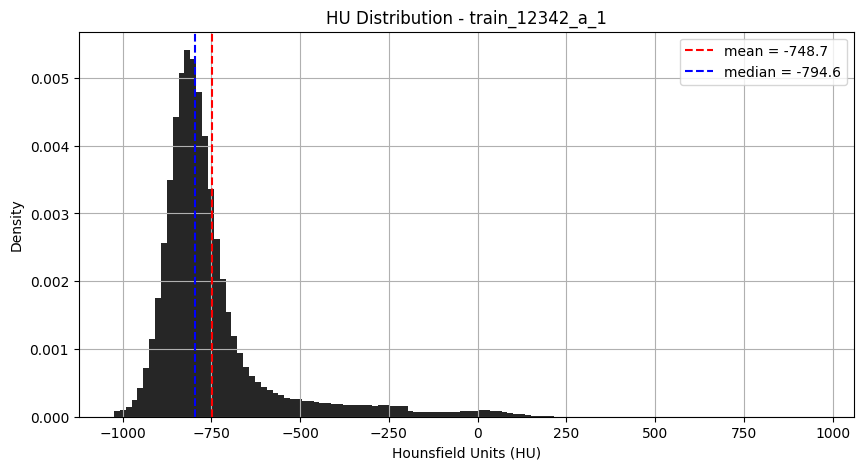

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume
from lc_ksvd.config import HU_MIN, HU_MAX


# -------------------------------------------------------
# Lung mask
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)

    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

normal_volume_names = labels.get_normal_volume_names()

print("Total CTs:", len(normal_volume_names))


# -------------------------------------------------------
# Store per CT
# -------------------------------------------------------
dataset = []


# -------------------------------------------------------
# Process CTs
# -------------------------------------------------------
for volume_name in tqdm(normal_volume_names, desc="Processing CTs"):

    try:
        vol_hu, spacing = load_volume(volume_name)
        vol_rs = resample_volume(vol_hu, spacing)

        lung_mask = build_lung_mask(vol_rs)
        lung_voxels = vol_rs[lung_mask].astype(np.float32)

        if lung_voxels.size == 0:
            continue

        dataset.append({
            "ct_name": volume_name,
            "voxels": lung_voxels
        })

    except Exception as e:
        print(f"Skipped {volume_name}: {e}")


# -------------------------------------------------------
# Save NPZ (with metadata)
# -------------------------------------------------------
output_file = "normal_lung_voxels_with_meta.npz"

np.savez_compressed(
    output_file,
    data=np.array(dataset, dtype=object)
)

print("\nSaved:", output_file)
print("Total CTs saved:", len(dataset))


# -------------------------------------------------------
# Load back example (test)
# -------------------------------------------------------
loaded = np.load(output_file, allow_pickle=True)
records = loaded["data"]

print("\nExample CT:")
print("CT name:", records[0]["ct_name"])
print("Voxel shape:", records[0]["voxels"].shape)


# -------------------------------------------------------
# Plot one CT HU distribution
# -------------------------------------------------------
voxels = records[0]["voxels"]

plt.figure(figsize=(10, 5))

plt.hist(voxels, bins=120, density=True, alpha=0.85, color="black")

plt.axvline(voxels.mean(), color="red", linestyle="--",
            label=f"mean = {voxels.mean():.1f}")

plt.axvline(np.median(voxels), color="blue", linestyle="--",
            label=f"median = {np.median(voxels):.1f}")

plt.title(f"HU Distribution - {records[0]['ct_name']}")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

In [6]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.segmentation import clear_border
from tqdm import tqdm

from lc_ksvd.config import HU_MIN, HU_MAX
from lc_ksvd.data_loader import LabelRegistry, MetadataRegistry, load_volume, resample_volume

print(">>> SCRIPT STARTED")
# -------------------------------------------------------
# Lung mask (your method)
# -------------------------------------------------------
def build_lung_mask(vol):
    mask = (vol >= HU_MIN) & (vol <= HU_MAX)

    mask_clear = np.zeros_like(mask, dtype=bool)
    for z in range(mask.shape[2]):
        mask_clear[:, :, z] = clear_border(mask[:, :, z])

    labels, num = ndimage.label(mask_clear)

    if num > 0:
        sizes = ndimage.sum(mask_clear, labels, range(1, num + 1))

        if len(sizes) >= 2:
            largest_two = np.argsort(sizes)[-2:] + 1
            lung_mask = np.isin(labels, largest_two)
        else:
            lung_mask = labels > 0
    else:
        lung_mask = mask_clear

    structure = ndimage.generate_binary_structure(3, 2)
    lung_mask = ndimage.binary_closing(lung_mask, structure=structure, iterations=2)
    lung_mask = ndimage.binary_fill_holes(lung_mask)

    return lung_mask


# -------------------------------------------------------
# Init
# -------------------------------------------------------
metadata = MetadataRegistry(split=None)
labels = LabelRegistry(metadata, split=None)

abnormalities = ["2b", "2c", "2d"]

output_dir = Path("/home/chest_ct/code/models/lc-ksvd/eda_outputs/npz_voxels")
output_dir.mkdir(parents=True, exist_ok=True)

bins = np.arange(-1000, 251, 10)


# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
for category in abnormalities:

    print(f"\nProcessing category: {category}")

    volume_names = labels.get_positive_volume_names(category)

    all_lung_voxels = []

    # ---------------------------
    # Collect voxels
    # ---------------------------
    for volume_name in tqdm(volume_names, desc=f"Processing {category}", unit="vol"):

        try:
            vol_hu, spacing = load_volume(volume_name)
            vol_rs = resample_volume(vol_hu, spacing)

            lung_mask = build_lung_mask(vol_rs)
            lung_voxels = vol_rs[lung_mask].astype(np.float32)

            if lung_voxels.size > 0:
                all_lung_voxels.append(lung_voxels)

        except Exception as e:
            print(f"Skipped {volume_name}: {e}")

    if not all_lung_voxels:
        print(f"No data for {category}")
        continue

    # ---------------------------
    # Merge voxels
    # ---------------------------
    all_lung_voxels = np.concatenate(all_lung_voxels).astype(np.float32)

    print(f"{category}: total voxels = {all_lung_voxels.size:,}")

    # ---------------------------
    # Save npz
    # ---------------------------
    save_path = output_dir / f"{category}_lung_voxels.npz"

    np.savez_compressed(save_path, voxels=all_lung_voxels)

    print(f"Saved: {save_path}")

    # ---------------------------
    # Plot distribution
    # ---------------------------
    plt.figure(figsize=(10, 5))

    hist, _ = np.histogram(all_lung_voxels, bins=bins, density=True)

    plt.plot(bins[:-1], hist, linewidth=2, label=f"{category}")

    plt.axvline(all_lung_voxels.mean(), color="red", linestyle="--",
                label=f"mean = {all_lung_voxels.mean():.1f}")

    plt.axvline(np.median(all_lung_voxels), color="blue", linestyle="--",
                label=f"median = {np.median(all_lung_voxels):.1f}")

    plt.title(f"HU Distribution (Lung Voxels) - {category}")
    plt.xlabel("Hounsfield Units (HU)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

>>> SCRIPT STARTED

Processing category: 2b


Processing 2b: 0vol [00:00, ?vol/s]


No data for 2b

Processing category: 2c


Processing 2c:   3%|▎         | 33/1176 [01:31<52:50,  2.77s/vol]


KeyboardInterrupt: 

Total CT scans: 347

===== GLOBAL HU STATISTICS =====
Total voxels: 512,300,757
Min HU: -29001.77
Mean HU: -789.81
Median HU: -846.92
Max HU: 29808.06

Percentiles:
P1: -1010.27
P5: -954.96
P25: -890.66
P50: -846.92
P75: -769.66
P95: -350.17
P99: -28.53

===== PER-CT SUMMARY (first 5) =====

CT: train_12342_a_1
  Voxels: 647,180
  Min/Mean/Median/Max: -1024.0 / -748.7 / -794.6 / 960.1

CT: train_10990_a_1
  Voxels: 1,798,687
  Min/Mean/Median/Max: -1024.0 / -841.5 / -888.7 / 3071.0

CT: train_9664_a_1
  Voxels: 1,203,990
  Min/Mean/Median/Max: -1024.0 / -736.4 / -788.2 / 628.7

CT: train_2863_a_1
  Voxels: 1,340,260
  Min/Mean/Median/Max: -1023.9 / -763.3 / -819.7 / 320.8

CT: train_5462_a_2
  Voxels: 3,010,804
  Min/Mean/Median/Max: -1024.0 / -848.0 / -893.5 / 1177.1


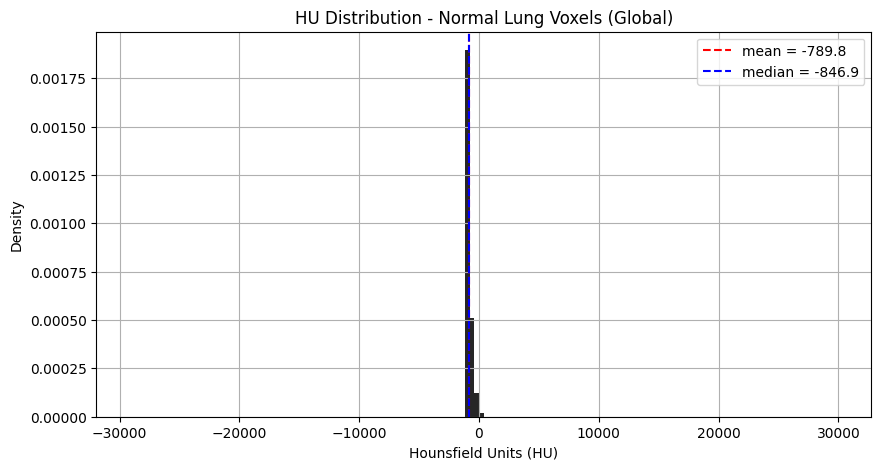

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Load dataset
# -------------------------------------------------------
file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

print("Total CT scans:", len(records))


# -------------------------------------------------------
# Collect all voxels (global distribution)
# -------------------------------------------------------
all_voxels = np.concatenate([r["voxels"] for r in records]).astype(np.float32)

print("\n===== GLOBAL HU STATISTICS =====")
print(f"Total voxels: {all_voxels.size:,}")
print(f"Min HU: {all_voxels.min():.2f}")
print(f"Mean HU: {all_voxels.mean():.2f}")
print(f"Median HU: {np.median(all_voxels):.2f}")
print(f"Max HU: {all_voxels.max():.2f}")

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"P{p}: {np.percentile(all_voxels, p):.2f}")


# -------------------------------------------------------
# Per-CT statistics
# -------------------------------------------------------
print("\n===== PER-CT SUMMARY (first 5) =====")

for r in records[:5]:
    v = r["voxels"]
    print(f"\nCT: {r['ct_name']}")
    print(f"  Voxels: {v.size:,}")
    print(f"  Min/Mean/Median/Max: "
          f"{v.min():.1f} / {v.mean():.1f} / {np.median(v):.1f} / {v.max():.1f}")


# -------------------------------------------------------
# Histogram (global)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=150, density=True, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

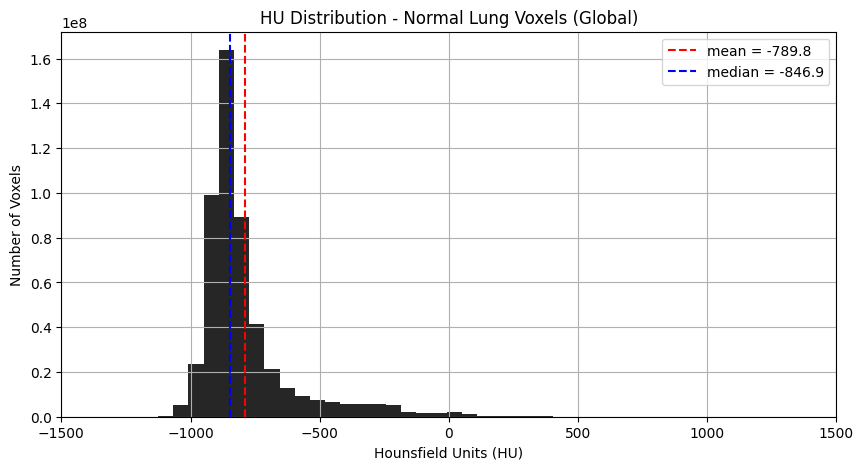

In [16]:
# -------------------------------------------------------
# Histogram (global - voxel counts)
# -------------------------------------------------------
plt.figure(figsize=(10, 5))

plt.hist(all_voxels, bins=1000, alpha=0.85, color="black")

plt.axvline(all_voxels.mean(), color="red", linestyle="--",
            label=f"mean = {all_voxels.mean():.1f}")

plt.axvline(np.median(all_voxels), color="blue", linestyle="--",
            label=f"median = {np.median(all_voxels):.1f}")

plt.title("HU Distribution - Normal Lung Voxels (Global)")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Number of Voxels")   # changed

plt.xlim(-1500,1500)

plt.legend()
plt.grid(True)

plt.show()

In [8]:
import numpy as np

file_path = "/home/chest_ct/code/models/lc-ksvd/src/lc_ksvd/normal_lung_voxels_with_meta.npz"

data = np.load(file_path, allow_pickle=True)
records = data["data"]

bad_cts = []

# -------------------------------------------------------
# Scan per CT
# -------------------------------------------------------
for r in records:

    voxels = r["voxels"]

    min_v = float(voxels.min())
    max_v = float(voxels.max())

    # threshold for abnormal CT intensity
    if min_v < -1024 or max_v > 3071:
        bad_cts.append({
            "ct_name": r["ct_name"],
            "min": min_v,
            "max": max_v,
            "voxels": voxels.size
        })


# -------------------------------------------------------
# Sort by worst extreme value
# -------------------------------------------------------
bad_cts_sorted = sorted(
    bad_cts,
    key=lambda x: max(abs(x["min"]), abs(x["max"])),
    reverse=True
)


# -------------------------------------------------------
# Print results
# -------------------------------------------------------
print("===== EXTREME CT SCANS =====")
print(f"Total bad CTs: {len(bad_cts_sorted)}\n")

for c in bad_cts_sorted[:20]:
    print(f"CT: {c['ct_name']}")
    print(f"  Min HU: {c['min']:.1f}")
    print(f"  Max HU: {c['max']:.1f}")
    print(f"  Voxels: {c['voxels']:,}")
    print("-" * 40)

===== EXTREME CT SCANS =====
Total bad CTs: 73

CT: train_136_a_2
  Min HU: -29001.8
  Max HU: 29808.1
  Voxels: 1,550,125
----------------------------------------
CT: train_9186_a_2
  Min HU: -4070.3
  Max HU: 28247.3
  Voxels: 1,153,184
----------------------------------------
CT: train_13441_a_2
  Min HU: -1024.0
  Max HU: 27554.0
  Voxels: 1,683,685
----------------------------------------
CT: train_12958_a_2
  Min HU: -11584.0
  Max HU: 26201.3
  Voxels: 1,385,587
----------------------------------------
CT: train_18518_a_2
  Min HU: -4135.8
  Max HU: 26154.6
  Voxels: 1,614,320
----------------------------------------
CT: train_19847_a_2
  Min HU: -4101.8
  Max HU: 22922.2
  Voxels: 1,299,852
----------------------------------------
CT: train_4255_a_2
  Min HU: -1024.0
  Max HU: 22365.3
  Voxels: 1,542,150
----------------------------------------
CT: train_5977_a_2
  Min HU: -2472.4
  Max HU: 19390.8
  Voxels: 737,412
----------------------------------------
CT: train_19464_a_2
 